# Tech Challenge Fase 3 — Análise Exploratória de Dados (EDA)
### Indicador Criança Alfabetizada

**Objetivo desta etapa:** compreender o comportamento da base (camada Gold),
identificar padrões, distribuições, correlações e formular hipóteses
analíticas que vão apoiar as decisões de modelagem na próxima etapa.

> ⚠️ **Nota:** esta EDA está sendo executada sobre uma base **simulada**
> (`data/gold_alfabetizacao_simulado.csv`), construída para viabilizar o
> desenvolvimento da pipeline antes da base real da Fase 2 estar disponível.
> Assim que a base real existir, basta apontar o `pd.read_csv` para o
> arquivo real — todo o restante da análise permanece válido, desde que as
> colunas sejam equivalentes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("../data/gold_alfabetizacao_simulado.csv")
df.shape


(8000, 22)

## 1. Visão geral da base

In [2]:
df.head()


,id_aluno,ano_referencia,regiao,uf,zona,porte_municipio,populacao_municipio,sexo,idade_meses,renda_per_capita,...,beneficiario_bolsa_familia,inse_escola,infraestrutura_escola,professores_formacao_adequada_pct,razao_aluno_professor,taxa_frequencia_creche_pre,meta_estadual_alfabetizacao,municipio_atingiu_meta_anterior,frequencia_escolar_pct,alfabetizado
0,1,2023,Sudeste,MG,Rural,Médio,56264,M,86,694.46,...,0,4.28,7.68,85.27,21.66,84.79,73.84,0,81.53,0
1,2,2023,Sudeste,ES,Urbana,Pequeno,10960,M,87,1127.71,...,0,4.32,7.28,90.53,20.94,49.38,67.38,1,93.55,0
2,3,2024,Nordeste,AL,Urbana,Médio,160465,M,97,415.71,...,0,NaN,7.88,53.41,26.47,25.21,66.83,1,92.49,1
3,4,2023,Nordeste,AL,Urbana,Pequeno,18517,M,99,673.19,...,0,5.25,4.65,60.95,21.07,33.97,70.93,0,90.65,0
4,5,2022,Centro-Oeste,DF,Urbana,Grande,10921252,F,101,693.63,...,1,5.94,4.66,67.52,18.10,54.65,74.45,0,90.10,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id_aluno                           8000 non-null   int64  
 1   ano_referencia                     8000 non-null   int64  
 2   regiao                             8000 non-null   str    
 3   uf                                 8000 non-null   str    
 4   zona                               8000 non-null   str    
 5   porte_municipio                    8000 non-null   str    
 6   populacao_municipio                8000 non-null   int64  
 7   sexo                               8000 non-null   str    
 8   idade_meses                        8000 non-null   int64  
 9   renda_per_capita                   7611 non-null   float64
 10  idh_municipio                      8000 non-null   float64
 11  taxa_pobreza                       8000 non-null   float64
 12  ben

In [4]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
id_aluno,8000.0,4000.500000,2.309545e+03,1.000,2000.7500,4000.500,6000.2500,8000.00
ano_referencia,8000.0,2023.004250,8.202536e-01,2022.000,2022.0000,2023.000,2024.0000,2024.00
populacao_municipio,8000.0,991792.986750,2.591339e+06,2004.000,10276.7500,18462.500,143139.0000,11996729.00
idade_meses,8000.0,95.467125,6.946722e+00,84.000,89.0000,96.000,101.0000,107.00
renda_per_capita,7611.0,920.427689,2.710386e+02,150.000,736.9250,921.150,1103.5900,2046.35
idh_municipio,8000.0,0.685082,6.333177e-02,0.446,0.6440,0.686,0.7280,0.90
taxa_pobreza,8000.0,24.455060,8.921106e+00,1.000,18.3700,24.300,30.5800,59.37
beneficiario_bolsa_familia,8000.0,0.343250,4.748238e-01,0.000,0.0000,0.000,1.0000,1.00
inse_escola,7667.0,5.079551,1.261201e+00,1.000,4.2200,5.080,5.9200,9.00
infraestrutura_escola,8000.0,6.071170,1.519905e+00,0.160,5.0300,6.070,7.1100,10.00


## 2. Valores faltantes

Verificar quais colunas possuem dados ausentes e em qual proporção — isso
vai orientar a estratégia de imputação na etapa de modelagem (a pipeline
final deverá tratar isso via `SimpleImputer` ou similar, **dentro** do
pipeline do Scikit-learn, nunca antes da separação treino/teste, para
evitar data leakage).


In [5]:
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
pct_faltantes = (faltantes / len(df) * 100).round(2)

pd.DataFrame({"qtd_faltantes": faltantes, "pct_faltantes": pct_faltantes})


,qtd_faltantes,pct_faltantes
renda_per_capita,389,4.86
inse_escola,333,4.16
frequencia_escolar_pct,225,2.81


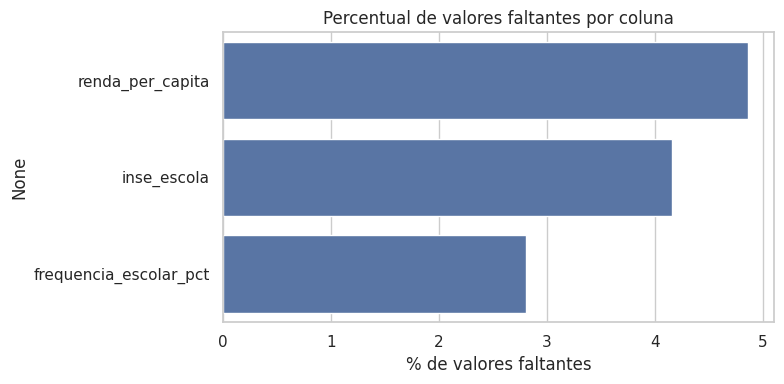

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(x=pct_faltantes.values, y=pct_faltantes.index, color="#4C72B0")
plt.xlabel("% de valores faltantes")
plt.title("Percentual de valores faltantes por coluna")
plt.tight_layout()
plt.savefig("../images/01_valores_faltantes.png", dpi=120)
plt.show()


## 3. Distribuição da variável-alvo (`alfabetizado`)

Entender o balanceamento das classes é essencial: se houver desbalanceamento
relevante, isso deve ser tratado na modelagem (ex: `class_weight='balanced'`,
reamostragem, ou escolha de métrica que não seja só acurácia — como F1,
recall da classe minoritária, ou AUC).


alfabetizado
Não alfabetizado    0.62425
Alfabetizado        0.37575
Name: proportion, dtype: float64


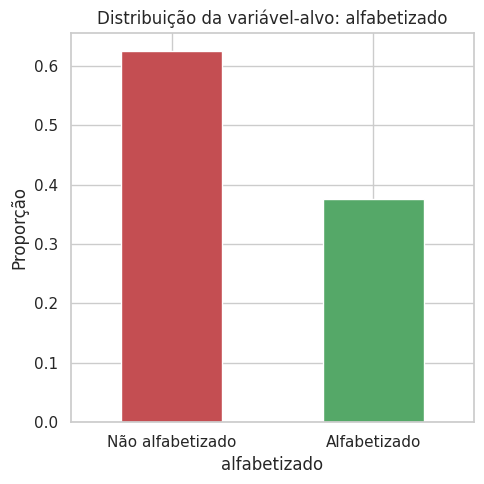

In [7]:
dist_alvo = df["alfabetizado"].value_counts(normalize=True).rename({0: "Não alfabetizado", 1: "Alfabetizado"})
print(dist_alvo)

plt.figure(figsize=(5, 5))
dist_alvo.plot(kind="bar", color=["#C44E52", "#55A868"])
plt.ylabel("Proporção")
plt.title("Distribuição da variável-alvo: alfabetizado")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/02_distribuicao_alvo.png", dpi=120)
plt.show()


**Hipótese H0 (referência):** existe desbalanceamento moderado entre as
classes. Isso será considerado na escolha de métricas e possivelmente de
técnicas de balanceamento durante a modelagem.


## 4. Distribuições das variáveis numéricas

Analisar forma, assimetria e possíveis outliers das principais variáveis
socioeconômicas e educacionais.


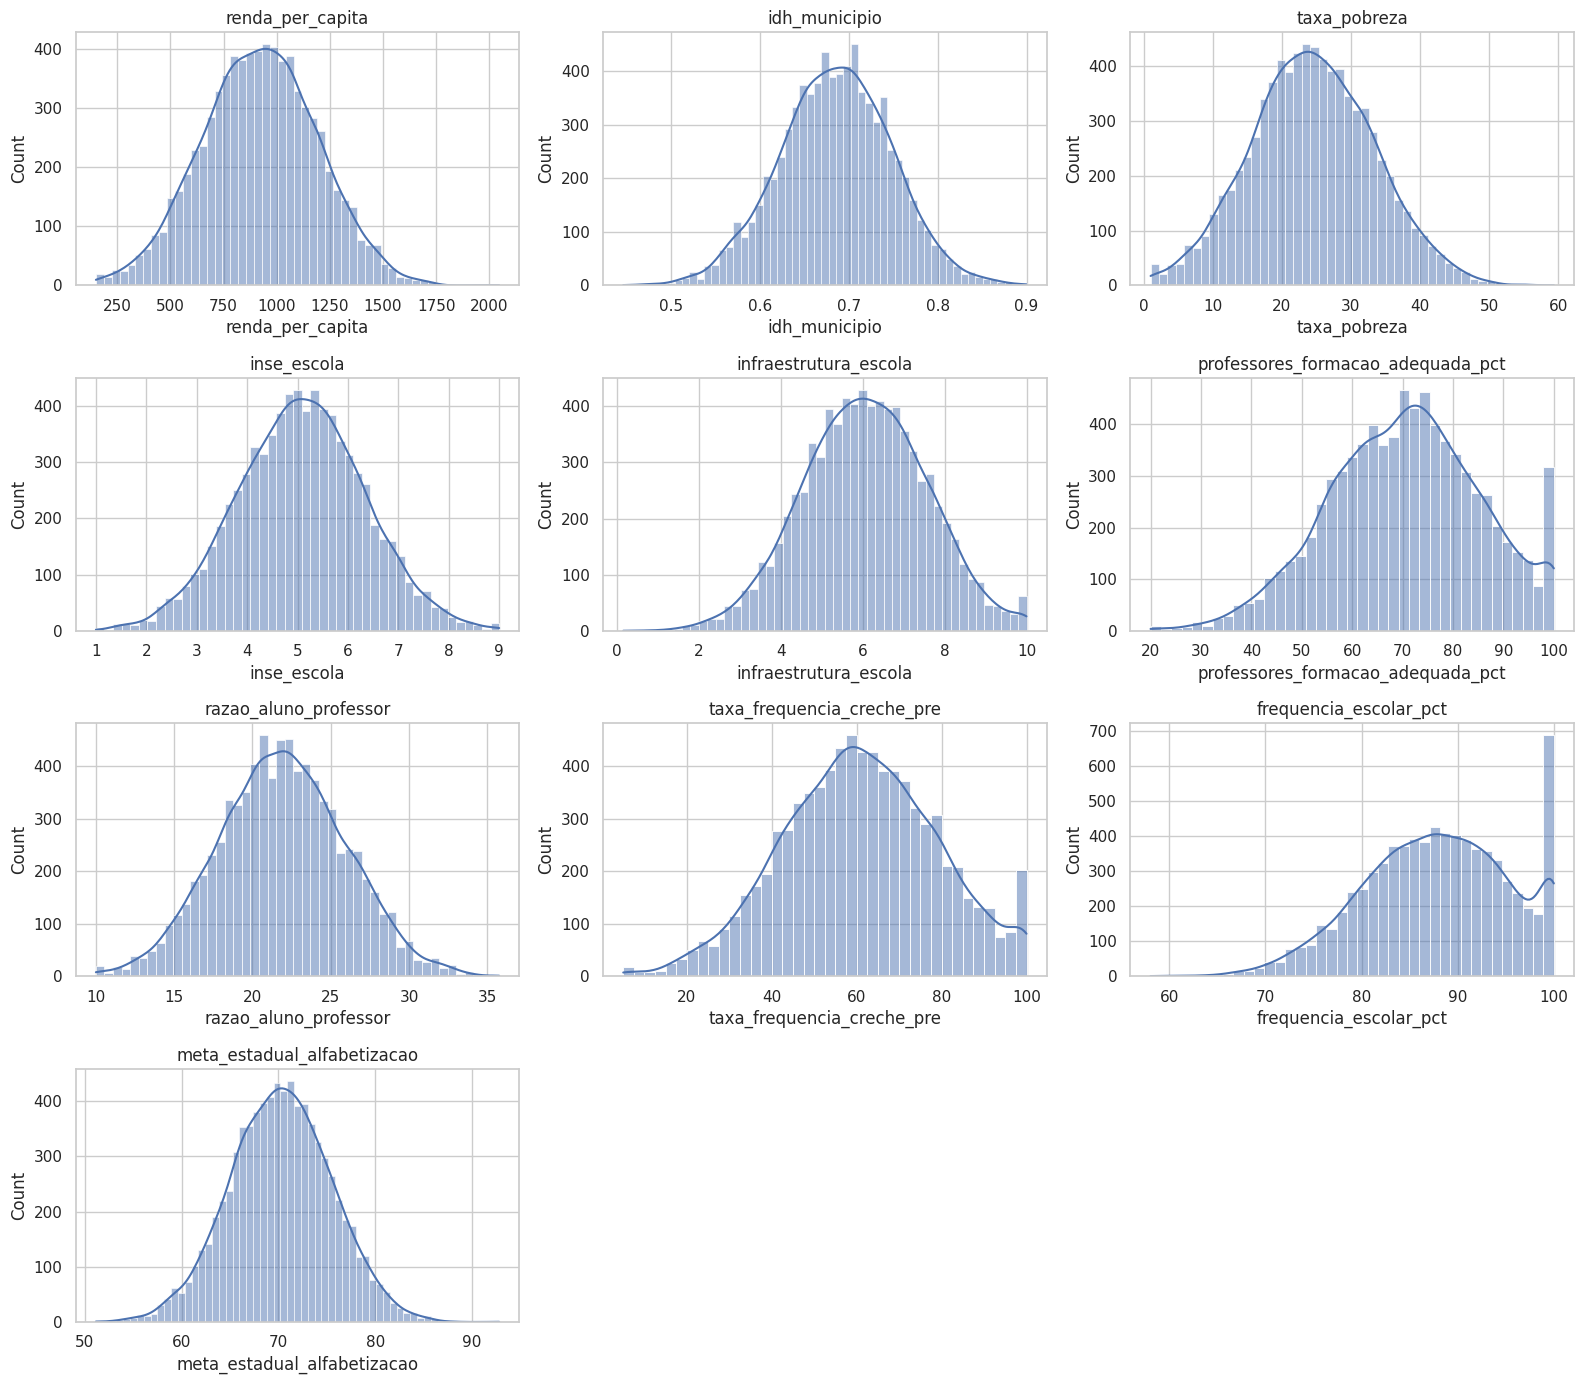

In [8]:
num_cols = [
    "renda_per_capita", "idh_municipio", "taxa_pobreza", "inse_escola",
    "infraestrutura_escola", "professores_formacao_adequada_pct",
    "razao_aluno_professor", "taxa_frequencia_creche_pre",
    "frequencia_escolar_pct", "meta_estadual_alfabetizacao",
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/03_distribuicoes_numericas.png", dpi=120)
plt.show()


## 5. Variáveis numéricas vs. variável-alvo

Comparar a distribuição de cada variável entre alunos alfabetizados e não
alfabetizados ajuda a identificar quais fatores mais se relacionam com o
desfecho — insumo direto para a etapa de *feature importance* na modelagem.


/tmp/ipykernel_607/2318189676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="alfabetizado", y=col, ax=axes[i], palette=["#C44E52", "#55A868"])
/tmp/ipykernel_607/2318189676.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Não alfabetizado", "Alfabetizado"])
/tmp/ipykernel_607/2318189676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="alfabetizado", y=col, ax=axes[i], palette=["#C44E52", "#55A868"])
/tmp/ipykernel_607/2318189676.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a 

/tmp/ipykernel_607/2318189676.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Não alfabetizado", "Alfabetizado"])
/tmp/ipykernel_607/2318189676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="alfabetizado", y=col, ax=axes[i], palette=["#C44E52", "#55A868"])
/tmp/ipykernel_607/2318189676.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Não alfabetizado", "Alfabetizado"])
/tmp/ipykernel_607/2318189676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

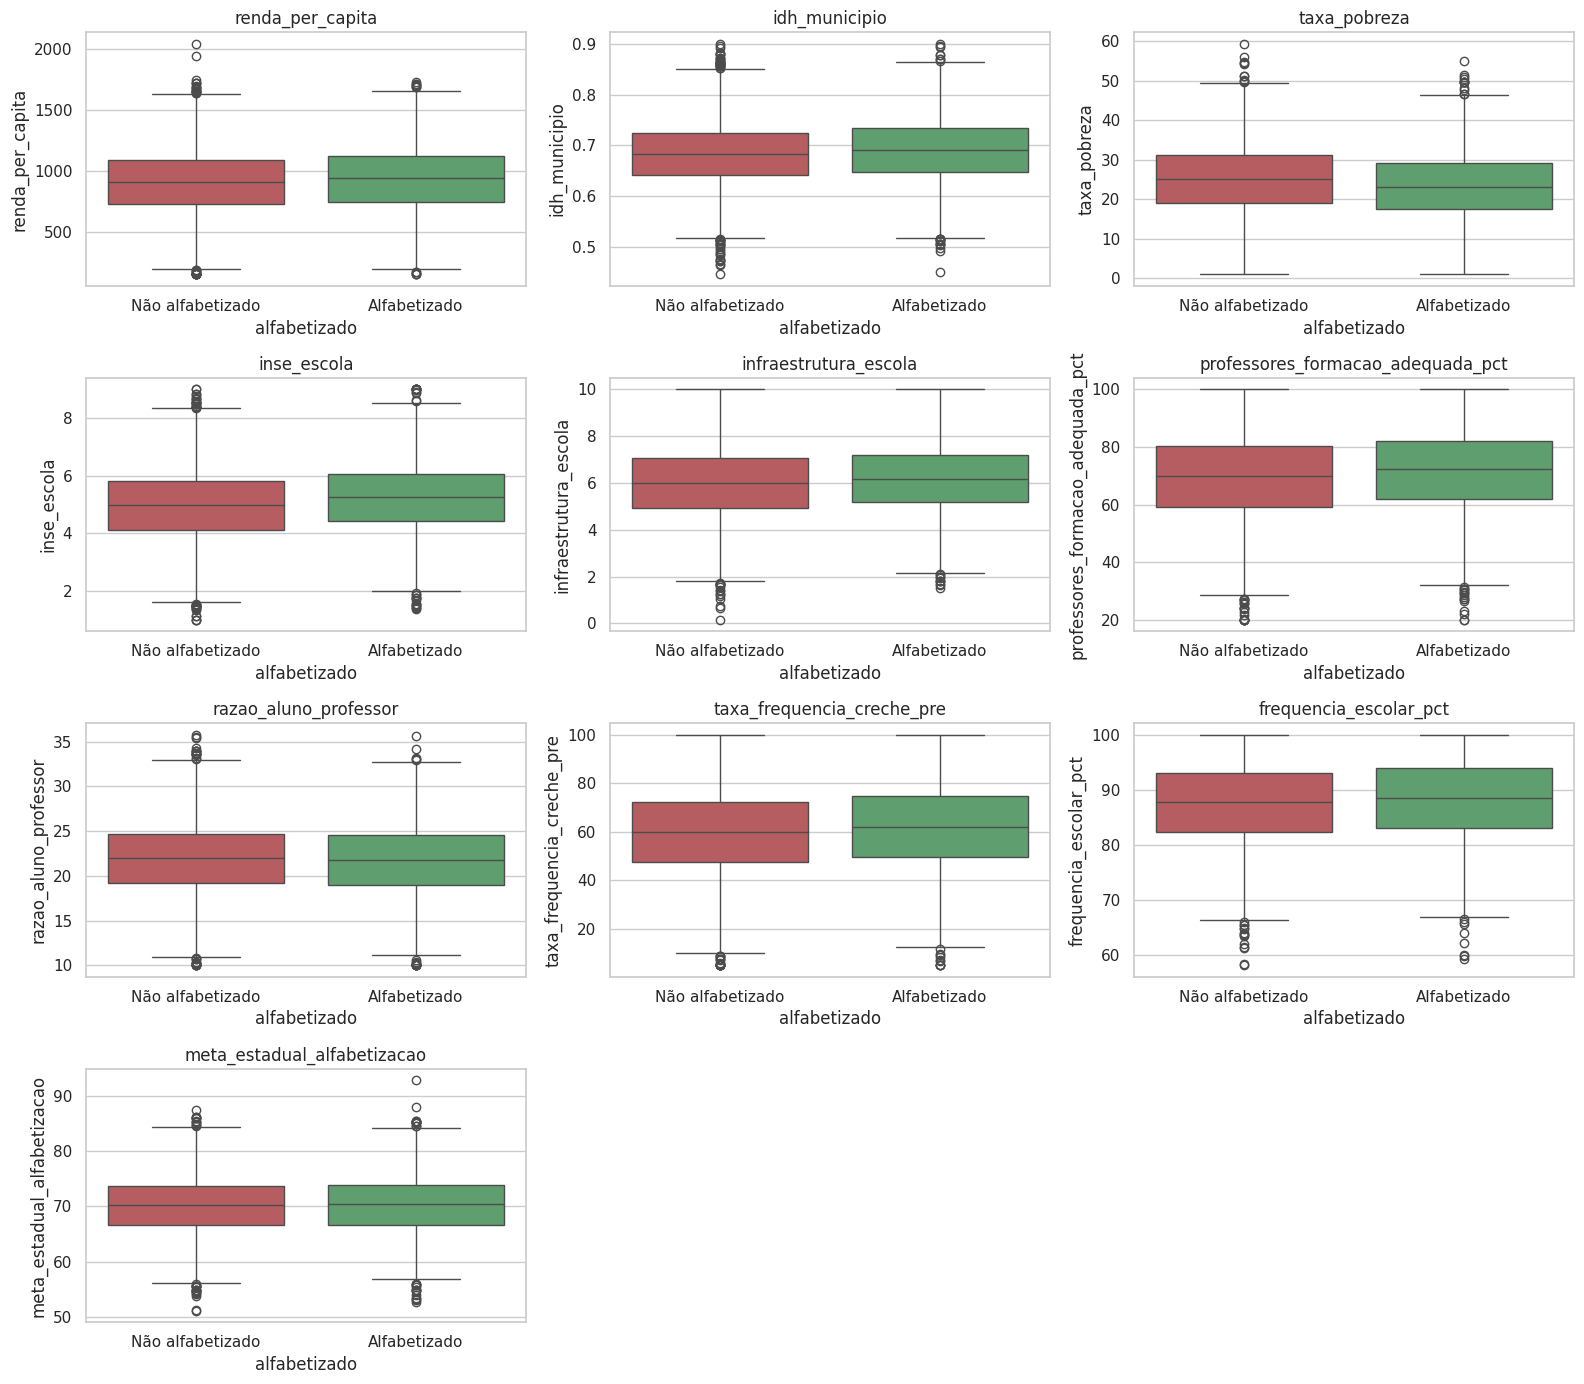

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="alfabetizado", y=col, ax=axes[i], palette=["#C44E52", "#55A868"])
    axes[i].set_xticklabels(["Não alfabetizado", "Alfabetizado"])
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/04_boxplots_vs_alvo.png", dpi=120)
plt.show()


## 6. Correlação entre variáveis numéricas

Correlações fortes entre preditoras podem indicar necessidade de tratamento
(ex: remoção/combinação de variáveis redundantes). Também observamos a
correlação de cada variável com o alvo.


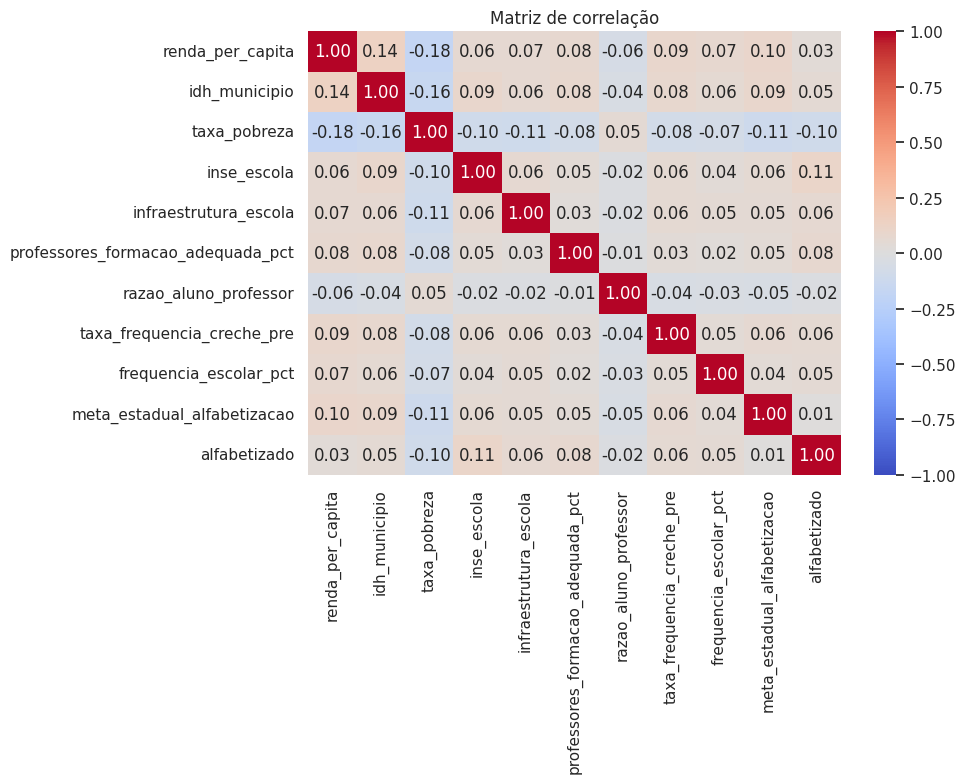

In [10]:
corr_cols = num_cols + ["alfabetizado"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.savefig("../images/05_matriz_correlacao.png", dpi=120)
plt.show()


In [11]:
corr["alfabetizado"].drop("alfabetizado").sort_values(key=abs, ascending=False)


inse_escola                          0.105568
taxa_pobreza                        -0.098455
professores_formacao_adequada_pct    0.076863
infraestrutura_escola                0.062617
taxa_frequencia_creche_pre           0.060768
idh_municipio                        0.053189
frequencia_escolar_pct               0.050111
renda_per_capita                     0.033587
razao_aluno_professor               -0.022193
meta_estadual_alfabetizacao          0.008134
Name: alfabetizado, dtype: float64

## 7. Variáveis categóricas e territoriais vs. alfabetização

Análise de como a taxa de alfabetização varia por região, zona (urbana/
rural), porte do município e outras categorias — direcionado às perguntas
de negócio do desafio (quais regiões/municípios apresentam maior risco
educacional).


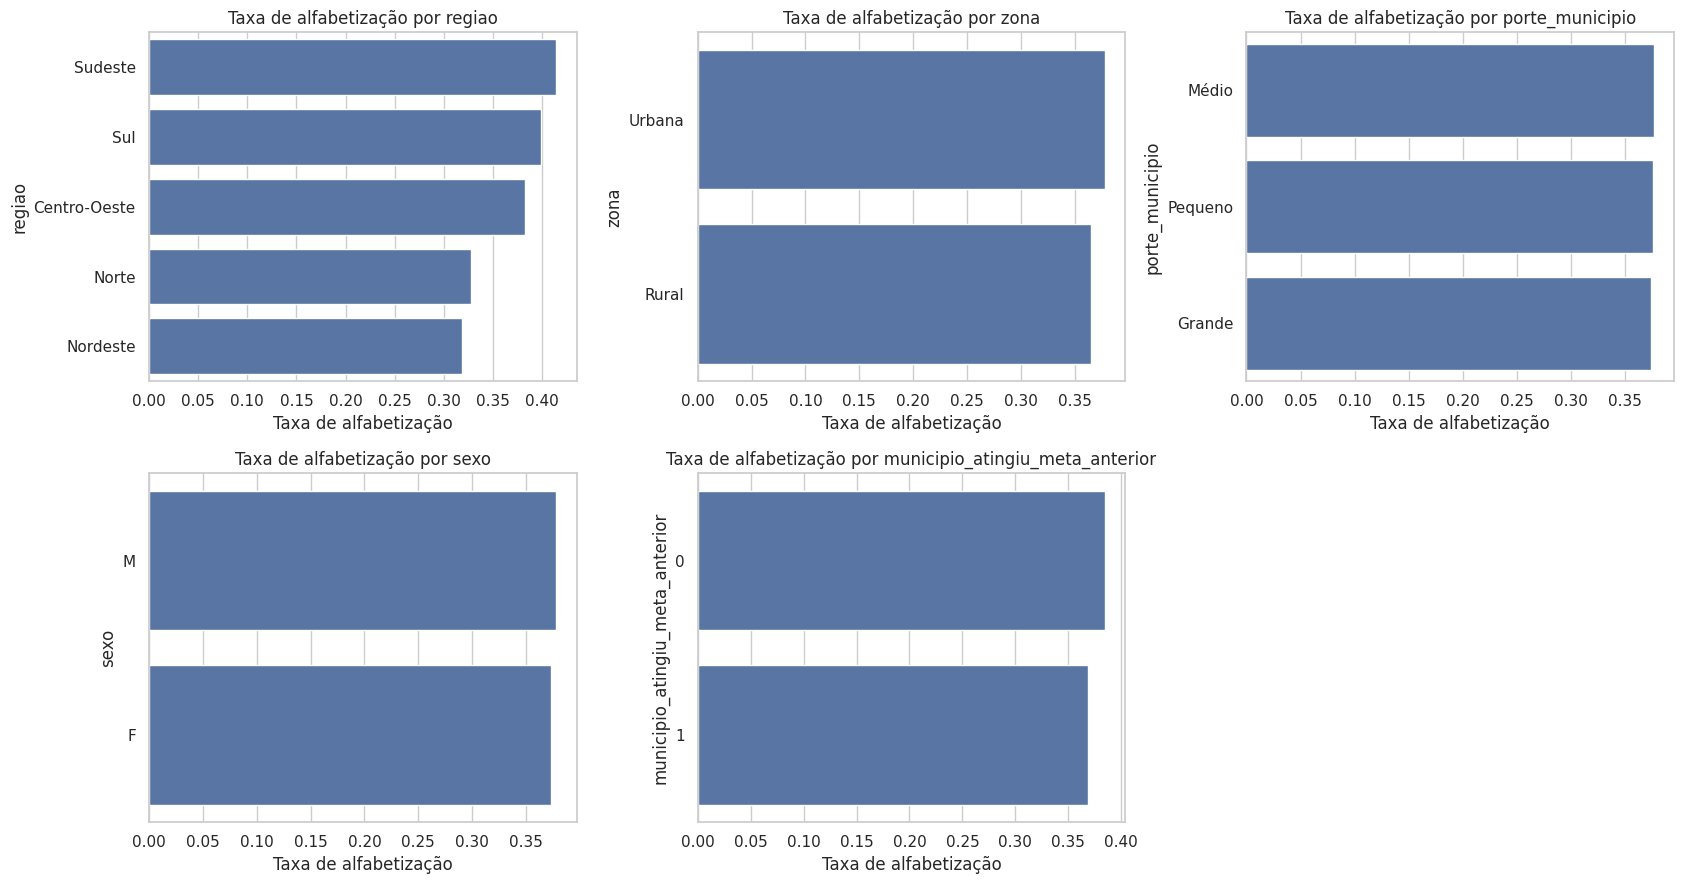

In [12]:
cat_cols = ["regiao", "zona", "porte_municipio", "sexo", "municipio_atingiu_meta_anterior"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    taxa = df.groupby(col)["alfabetizado"].mean().sort_values(ascending=False)
    sns.barplot(x=taxa.values, y=taxa.index.astype(str), ax=axes[i], color="#4C72B0")
    axes[i].set_xlabel("Taxa de alfabetização")
    axes[i].set_title(f"Taxa de alfabetização por {col}")
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../images/06_taxa_por_categoria.png", dpi=120)
plt.show()


## 8. Taxa de alfabetização por região (mapa de risco simplificado)

Resposta direta a uma das perguntas de negócio do desafio: **quais regiões
apresentam maior risco educacional?**


In [13]:
risco_regiao = (
    df.groupby("regiao")["alfabetizado"]
    .agg(taxa_alfabetizacao="mean", n_alunos="count")
    .sort_values("taxa_alfabetizacao")
)
risco_regiao["taxa_alfabetizacao"] = (risco_regiao["taxa_alfabetizacao"] * 100).round(1)
risco_regiao


,taxa_alfabetizacao,n_alunos
regiao,,
Nordeste,31.8,2180
Norte,32.7,688
Centro-Oeste,38.3,630
Sul,39.9,1168
Sudeste,41.4,3334


## 9. Hipóteses analíticas (síntese preliminar)

Com base nesta EDA inicial sobre a base simulada (**revisar após rodar com
a base real** — os coeficientes abaixo são específicos desta simulação):

1. **H1 — Nenhuma variável isolada explica sozinha a alfabetização; o
   efeito é multifatorial.** As correlações individuais com o alvo são
   todas fracas (|r| < 0.11), o que é esperado em fenômenos
   socioeconômicos complexos — reforça a necessidade de um modelo
   multivariado (e não de regras simples baseadas em 1-2 variáveis) e de
   técnicas de interpretabilidade como SHAP para capturar interações.
2. **H2 — O nível socioeconômico da escola (INSE) e a taxa de pobreza do
   município foram, isoladamente, as variáveis mais associadas ao
   desfecho** nesta simulação, sugerindo que tanto o ambiente escolar
   quanto o contexto territorial/familiar têm papel relevante.
3. **H3 — Formação docente e infraestrutura escolar têm relação positiva,
   porém moderada, com a alfabetização** — indicam alavancas de política
   pública no âmbito da escola, complementares às políticas
   socioeconômicas mais amplas.
4. **H4 — Existe heterogeneidade regional** nas taxas de alfabetização
   (ver seção 8), reforçando a necessidade de políticas regionalizadas em
   vez de metas nacionais únicas.
5. **H5 — Há desbalanceamento de classes** (~62% / 38%) que deve ser
   considerado na escolha de métricas e técnicas de modelagem (evitar
   otimizar apenas acurácia; priorizar F1, recall da classe minoritária ou
   AUC).

Essas hipóteses devem ser **revisitadas e validadas estatisticamente**
(testes de hipótese, feature importance, SHAP) na etapa de modelagem, e
servem como guia inicial — não como conclusão definitiva.

## 10. Próximos passos

- [ ] Validar hipóteses com testes estatísticos formais (ex: teste t,
      qui-quadrado para categóricas)
- [ ] Definir estratégia de tratamento de data leakage (ex: variáveis que
      só existem *depois* do desfecho não podem entrar no modelo)
- [ ] Construir pipeline de pré-processamento (`ColumnTransformer` +
      `Pipeline` do Scikit-learn)
- [ ] Treinar modelos baseline (Regressão Logística, Árvore) e comparar
      com modelos mais robustos (Random Forest, XGBoost/LightGBM)
- [ ] Aplicar Feature Importance / SHAP para interpretabilidade
